In [14]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import OrderedDict
from torch.utils.data import TensorDataset, DataLoader,Dataset
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from sklearn.pipeline import Pipeline

%matplotlib ipympl

In [15]:
#TODO: Fix LSP: https://github.com/jupyter-lsp/jupyterlab-lsp

In [16]:
DATA_PATH = os.path.join("..", "data", "crop-recommendation-dataset",
                         "Crop_recommendation.parquet.gzip")
RANDOM_STATE = 42

# Context
Precision agriculture is in trend nowadays. It helps the farmers to get informed decision about the farming strategy. Here, I present you a dataset which would allow the users to build a predictive model to recommend the most suitable crops to grow in a particular farm based on various parameters.

## Context
This dataset was build by augmenting datasets of rainfall, climate and fertilizer data available for India.

## Data fields
N - ratio of Nitrogen content in soil

P - ratio of Phosphorous content in soil

K - ratio of Potassium content in soil

temperature - temperature in degree Celsius

humidity - relative humidity in %

ph - ph value of the soil

rainfall - rainfall in mm

In [36]:
# data = pd.read_parquet(DATA_PATH)
# # label = data.pop('label')
# data_columns = data.columns
# data_index = data.index
# data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [72]:
# os.path.dirname(DATA_PATH)

'../data/crop-recommendation-dataset'

In [32]:
DATA_LABELS = ['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee']

In [40]:
# le = LabelEncoder()
# le.fit(DATA_LABELS)
# set(le.transform(data["label"]))

In [32]:
# import pyarrow.parquet as pq
# for batch in pq.ParquetFile(DATA_PATH).iter_batches(1):
#     columns = batch.column_names
#     label = columns.pop()
#     # yield self.dataScaler.transform(batch.to_tensor().to_numpy())
#     # label = table.drop(['col_B'])
#     print( batch.select(columns).to_tensor().to_numpy(),
#            batch.select([label]).to_pandas().to_numpy())
#     break

[[ 90.          42.          43.          20.87974371  82.00274423
    6.50298529 202.9355362 ]] [['rice']]


In [17]:
# data.to_parquet('Crop_recommendation.parquet.gzip',compression='gzip')

In [22]:
# print(f"{len(label.unique()) = }\n")
# label.head()

len(label.unique()) = 22



0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object

In [35]:
# # Data has no NAN
# data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


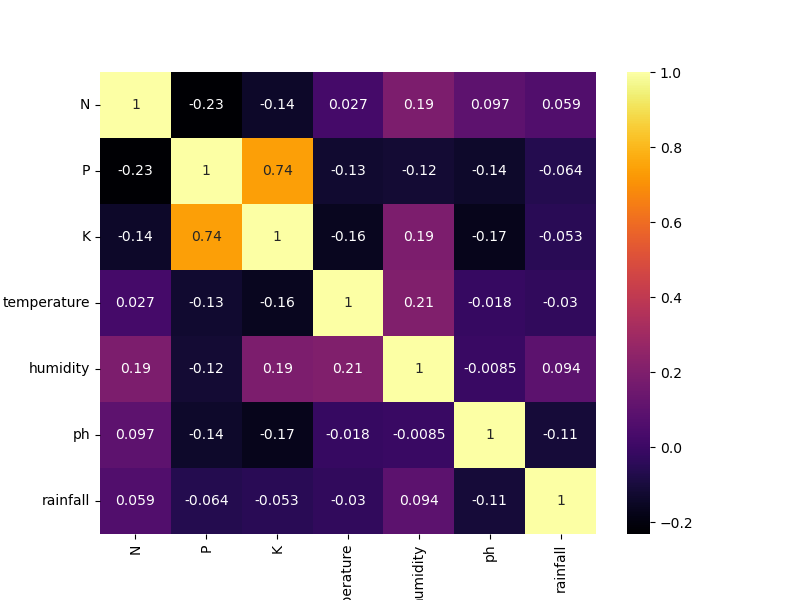

In [23]:
# corr_matrix = data.corr()
# filtered_corr_df = corr_matrix

# plt.figure(figsize=(8, 6))
# sns.heatmap(filtered_corr_df, annot=True, cmap="inferno")
# plt.show()

# # We could try apply a PCA to keep only 2 to 3 axis

# Pre-processing

## Data split with PCA


We will, for now, use all components

In [24]:
# scaler = StandardScaler()
# data = data.to_numpy()
# scaler.fit(data)

# pca = PCA(n_components=data.shape[1])
# pca.fit(data)
# data = pca.transform(data)

# X_train, X_test, y_train, y_test = train_test_split(data, label,
#                                                     test_size = 0.20,
#                                                     random_state = RANDOM_STATE,
#                                                     shuffle=True)

# X_train = scaler.transform(X_train)
# X_test = scaler.transform(X_test)

# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
#                                                     test_size = 0.10,
#                                                     random_state = RANDOM_STATE,
#                                                   shuffle=True)

# print(f"Train size: {X_train.size}\nVal size: {X_val.size}\nTest size: {X_test.size}")

Train size: 11088
Val size: 1232
Test size: 3080


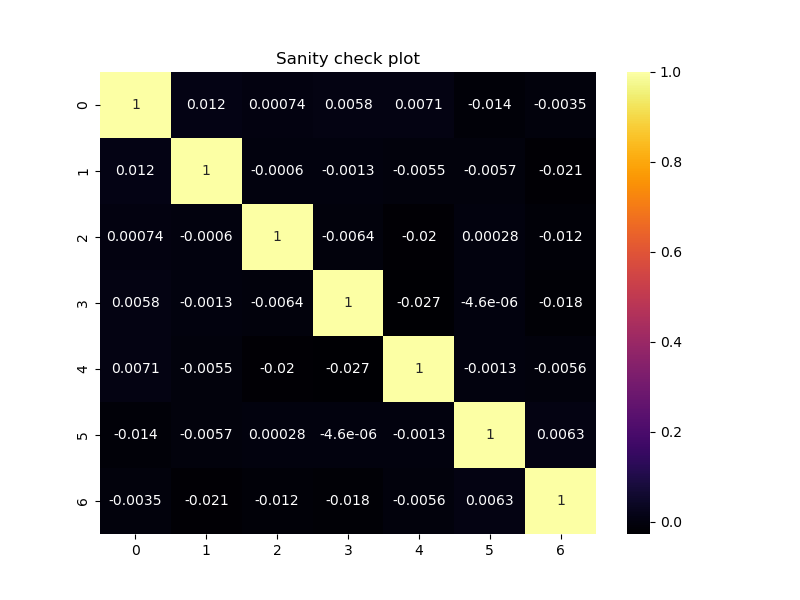

In [26]:
# size_samples = X_train.shape[0]
# filtered_corr_df = (pd.DataFrame(data=X_train[:size_samples])).corr()
# plt.figure(figsize=(8, 6))
# sns.heatmap(filtered_corr_df, annot=True, cmap="inferno")
# plt.title("Sanity check plot")
# plt.show()

# Torch Objects

# Model

In [10]:
class CropClassifier(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.fc1 = nn.Linear(7, 32)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)
        self.act2 = nn.Tanh()
        self.fc3 = nn.Linear(2, 16)
        self.act3 = nn.Tanh()
        self.fc4 = nn.Linear(16, 22)

    def forward(self, x):
        out = self.act1(self.fc1(x))
        out = self.act2(self.fc2(out))
        out = self.act3(self.fc3(out))
        out = self.fc4(out)
        return out

## Dataloader

### Utils.FileDataset.py

In [105]:
# import pyarrow.parquet as pq
# from pyarrow.parquet import ParquetFile
# import pyarrow as pa

# def _get_parquet_columns( file_path):
#     pf = ParquetFile(file_path)
#     first_ten_rows = next(pf.iter_batches(batch_size=1))
#     return pa.Table.from_batches([first_ten_rows]).to_pandas().columns
# list(_get_parquet_columns(DATA_PATH)).pop()

In [106]:
## Testing logic
# def _get_records_iterator(file_path):
#     # Replace this with logic to iterate over your specific data
#     for batch in pq.ParquetFile(file_path).iter_batches(1):
#         yield batch.to_pandas().to_numpy(),batch.to_pandas().to_numpy()[0]
# iterator1 = _get_records_iterator(DATA_PATH)
# a,b = next(iterator1)
# print(a)
# print("\n\n")
# print(b)

In [17]:
from torch.utils.data import IterableDataset, get_worker_info
import pyarrow.parquet as pq
from pathlib import Path
import pyarrow as pa


# https://apxml.com/courses/advanced-pytorch/chapter-3-optimization-training-strategies/large-dataset-strategies
class FileDataset(IterableDataset):
    """An iterable dataset for reading large Parquet files efficiently.

    This dataset is designed to work with PyTorch's DataLoader, supporting
    multi-process data loading by sharding the data across workers. It reads
    a Parquet file, separates features and labels, and applies normalization
    and label encoding on the fly.

    Attributes:
        file_path (str): The path to the input Parquet file.
        label (str): The name of the label column, assumed to be the last one.
        columns (list[str]): A list of feature column names.
        labelEncoder: An encoder object with a `transform` method for labels.
        normalizer: A normalizer object with a `transform` method for features.
    """
    def __init__(self, file_path, label_encoder, normalizer):
        """Initializes the FileDataset.

        Args:
            file_path (str): Path to the Parquet file.
            label_encoder: An object with a `transform` method to encode labels.
            normalizer: An object with a `transform` method to normalize features.

        Raises:
            ValueError: If the input file is not a '.parquet' or '.parquet.gzip' file.
        """
        super().__init__()
        if (Path(file_path).suffix == '.parquet' or
                Path(file_path).suffix == '.parquet.gzip'):
            raise ValueError("The input file shoud be a '.parquet.gzip' or \
            '.parquet.gzip'.")
        self.file_path = file_path
        fileColumns = self._get_parquet_columns(file_path)
        self.label = fileColumns.pop()
        self.columns = fileColumns
        self.labelEncoder = label_encoder
        self.normalizer = normalizer

    def _get_records_iterator(self):
        """Creates a generator to yield records from the Parquet file.

        This internal method iterates through the Parquet file one row at a time,
        yielding the features and the label for each row.

        Yields:
            tuple[numpy.ndarray, numpy.ndarray]: A tuple containing the feature
                data as a NumPy array and the label data as a NumPy array.
        """
        # Replace this with logic to iterate over your specific data
        for batch in pq.ParquetFile(self.file_path).iter_batches(1):
            yield (batch.select(self.columns).to_tensor().to_numpy(),
                   batch.select([self.label]).to_pandas().to_numpy())

    def __iter__(self):
        """Returns an iterator for the dataset.

        This method implements the core logic for an iterable-style dataset. It
        handles sharding the data across multiple workers for parallel loading.
        Each worker processes a unique subset of the data based on its worker ID.
        The normalization and label encoding are applied within this iterator.

        Returns:
            iterator: An iterator that yields tuples of (normalized_features,
                      encoded_label).
        """
        worker_info = get_worker_info()
        record_iterator, label = zip(*self._get_records_iterator())
        if worker_info is None:  # Single-process loading
            worker_id = 0
            num_workers = 1
        else:  # Multi-process loading
            worker_id = worker_info.id
            num_workers = worker_info.num_workers

        # Basic worker sharding: each worker processes every Nth record
        # Sophisticated sharding might involve byte offsets or file splitting
        sharded_iterator = ((self.normalizer.transform(record),
                             self.labelEncoder.transform(label[i][0])
                             ) for i, record in enumerate(record_iterator)
                            if i % num_workers == worker_id)

        # Apply processing within the worker's iterator chain
        # processed_iterator = map(self.processor_fn, sharded_iterator)
        return sharded_iterator

    def _get_parquet_columns(self, file_path: str) -> list:
        """Retrieves column names from a Parquet file.

        Reads the schema from the first batch of the Parquet file to infer the
        list of all column names.

        Args:
            file_path (str): The path to the Parquet file.

        Returns:
            list[str]: A list of column names present in the file.
        """
        pf = pq.ParquetFile(file_path)
        first_ten_rows = next(pf.iter_batches(batch_size=1))
        return list(pa.Table.from_batches([first_ten_rows]).to_pandas().columns)

In [18]:
from enum import Enum

class DatasetType(Enum):
    """Represents the standard dataset splits in a machine learning workflow.

    This enumeration provides standardized members for identifying a dataset's
    purpose, such as for training, validation, or testing.
    """
    TRAIN = "train"
    VAL = "val"
    TEST = "test"


In [19]:
class ProcessData:
    """Manages the preprocessing pipeline for a dataset.

    This class handles loading a raw dataset, fitting a label encoder and a
    feature normalizer, splitting the data into training, validation, and
    test sets, and providing access to these processed datasets.

    Attributes:
        data_path (str): The file path to the source dataset.
        data_labels (list[str]): The list of all possible class labels.
        lebel_encoder (LabelEncoder): The fitted label encoder.
        data_normalizer (Pipeline): The fitted feature processing pipeline,
            which includes normalization and optional dimensionality reduction.
    """

    def __init__(self, data_path: str, data_labels: list = None,
                 label_column="label", transformer=None):
        """Initializes the ProcessData object.

        This sets up the label encoder and fits the data normalizer pipeline
        based on the entire source dataset.

        Args:
            data_path (str): The path to the source Parquet data file.
            data_labels (list, optional): A list of class labels. If not
                provided, a default list is used. Defaults to None.
            label_column (str, optional): The name of the column containing
                the labels. Defaults to "label".
            transformer (object, optional): A scikit-learn compatible
                transformer class (e.g., PCA) to be applied after scaling.
                Defaults to None.
        """
        # TODO: Change label_column parameter value to **kargs
        # TODO: Add this labels to a config file
        self.data_path = data_path
        self.data_labels = ['rice', 'maize', 'chickpea', 'kidneybeans',
                            'pigeonpeas', 'mothbeans', 'mungbean', 'blackgram',
                            'lentil', 'pomegranate', 'banana', 'mango', 'grapes',
                            'watermelon', 'muskmelon', 'apple', 'orange', 'papaya',
                            'coconut', 'cotton', 'jute', 'coffee']
        self._generate_label_encoder()
        self._generate_data_normalizer(data_path, transformer)

    def _generate_label_encoder(self):
        """Initializes and fits the label encoder.

        Creates a scikit-learn LabelEncoder instance and fits it on the
        class's `data_labels` attribute.
        """
        self.lebel_encoder = LabelEncoder()
        self.lebel_encoder.fit(self.data_labels)

    def _generate_data_normalizer(self, data_path: str,
                                  transformer,
                                  label_column="label"):
        """Initializes and fits the data normalization and transformation pipeline.

        This method reads the feature data, fits a StandardScaler, and then
        optionally fits a subsequent transformer (like PCA) to create a
        complete preprocessing pipeline.

        Args:
            data_path (str): The path to the source Parquet data file.
            transformer (object): A scikit-learn transformer class to be
                applied after normalization.
            label_column (str): The name of the label column to exclude from
                fitting.
        """
        self.data_normalizer = StandardScaler()
        data = pd.read_parquet(data_path)
        data.pop(label_column)
        data = data.to_numpy()
        self.data_normalizer.fit(data)
        self.data_normalizer = Pipeline([('normalizer',  self.data_normalizer)])
        if transformer is not None:
            data = self.data_normalizer.transform(data)
            pca = transformer(n_components=7)
            pca.fit(data)
            self.data_normalizer = Pipeline([
                ('normalizer',  self.data_normalizer),
                ('pca',  pca)
            ])

    def split_and_shuffle_data(self, label_column='label',
                               test_size=0.2,
                               val_size=0.1,
                               RANDOM_STATE=42):
        """Shuffles and splits the source data into train, validation, and test sets.

        This method reads the source Parquet file, shuffles it, splits it,
        and saves three new Parquet files (train, val, test) in the same
        directory as the source file.

        Args:
            label_column (str, optional): The name of the label column.
                Defaults to 'label'.
            test_size (float, optional): The proportion of the dataset to
                allocate to the test split. Defaults to 0.2.
            val_size (float, optional): The proportion of the remaining training
                data to allocate to the validation split. Defaults to 0.1.
            RANDOM_STATE (int, optional): The seed for the random number
                generator for reproducibility. Defaults to 42.

        Raises:
            TypeError: If it fails to write one of the output Parquet files.
        """
        file_name = os.path.basename(self.data_path)
        dir_path = os.path.dirname(self.data_path)
        data = pd.read_parquet(self.data_path)
        # Shuffle data
        data = data.sample(frac=1).reset_index(drop=True)
        data_train, data_test = train_test_split(data,
                                                 test_size=test_size,
                                                 random_state=RANDOM_STATE,
                                                 shuffle=True)
        data_train, data_val = train_test_split(data_train,
                                                test_size=val_size,
                                                random_state=RANDOM_STATE,
                                                shuffle=True)
        try:
            data_test.to_parquet(os.path.join(dir_path,
                                              f'{DatasetType.TEST.value}_{file_name}'),
                                 compression='gzip')
            data_val.to_parquet(os.path.join(dir_path,
                                             f'{DatasetType.VAL.value}_{file_name}'),
                                compression='gzip')
            data_train.to_parquet(os.path.join(dir_path,
                                               f'{DatasetType.TRAIN.value}_{file_name}'),
                                  compression='gzip')
        except Exception as e:
            raise TypeError(f"Could not write one of the split file. {str(e)}")

    def get_enum_dataset(self, dataset_type: str):
        """Retrieves a specific dataset split as a FileDataset object.

        Acts as a factory for creating FileDataset instances for the 'train',
        'val', or 'test' splits. The required split files must already exist.

        Args:
            dataset_type (str): The desired dataset type. Must be one of
                'train', 'val', or 'test'.

        Returns:
            FileDataset: An iterable dataset object ready for use with a
                PyTorch DataLoader.

        Raises:
            ValueError: If an invalid `dataset_type` is provided or if the
                corresponding data file for that split does not exist.
        """
        dir_path = os.path.dirname(self.data_path)
        file_name = os.path.basename(self.data_path)
        validated_type = DatasetType(dataset_type.lower())
        # TODO: If the current file do not exist, add a try-except to execute
        # split_and_shuffle_data and retrieve the data
        if (validated_type == DatasetType.TRAIN):
            file_path = os.path.join(dir_path,
                                     f'{DatasetType.TRAIN.value}_{file_name}')
            return FileDataset(file_path, self.lebel_encoder,
                               self.data_normalizer)
        if (validated_type == DatasetType.VAL):
            file_path = os.path.join(dir_path,
                                     f'{DatasetType.VAL.value}_{file_name}')
            return FileDataset(file_path, self.lebel_encoder,
                               self.data_normalizer)
        if (validated_type == DatasetType.TEST):
            file_path = os.path.join(dir_path,
                                     f'{DatasetType.TEST.value}_{file_name}')
            return FileDataset(file_path, self.lebel_encoder,
                               self.data_normalizer)
        raise ValueError(f"The current type {dataset_type} do not exist.\
        Please, run the split_and_shuffle_data before calling this method.")



In [20]:
class EarlyStopper:
    """A utility to stop model training early if a monitored metric stops improving.

    This helps prevent overfitting by halting the training process once the model's
    performance on a validation set ceases to improve for a specified number of
    consecutive epochs.

    Attributes:
        patience (int): The number of epochs to wait for improvement before
            triggering a stop.
        min_delta (float): The minimum change in the monitored metric to be
            considered an improvement.
        counter (int): The current count of epochs without improvement.
        min_validation_loss (float): The lowest validation loss observed so far.
    """

    def __init__(self, patience=1, min_delta=1e-5):
        """Initializes the EarlyStopper.

        Args:
            patience (int, optional): The number of epochs with no improvement
                after which training will be stopped. Defaults to 1.
            min_delta (float, optional): The minimum change in the monitored
                quantity to qualify as an improvement. This is meant to prevent
                stopping for trivial improvements. Defaults to 0.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        """Checks if the training process should be stopped.

        This method should be called once per epoch. It evaluates the current
        validation loss against the best loss seen so far and updates its
        internal counter.

        Args:
            validation_loss (float): The validation loss from the current epoch.

        Returns:
            bool: True if training should stop, False otherwise.
        """
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [64]:
from torcheval.metrics.functional import multiclass_precision

class Trainer:
    def __init__(self, model, data_processer: ProcessData,
                 batch_size=64):
        # self.training_set = training_set
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model = model.to(self.device)
        self.data_processer = data_processer
        self.model_results = {"loss": [],
                              "vloss": [],
                              "epoch": [],
                             "vmulticlass_precision":[]}
        self.batch_size = batch_size
        self.loss_function = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.AdamW(self.model.parameters(),
                                          lr=0.01)
        self.epochs = 100
        # Saves the training results
        self.woking_dir = None
        self.DEBUG = False

    def _generate_dataloader(self, dataset_type: DatasetType):
        """Given the numpy array, gnerate the train and val dataloader"""
        file_dataset = self.data_processer.get_enum_dataset(dataset_type.value)
        return DataLoader(file_dataset,
                          batch_size=self.batch_size,
                          pin_memory=True)

    def train_epoch(self, train_dataloader):
        running_loss = 0.
        last_loss = 0.
        self.model.train(True)

        for index, data in enumerate(train_dataloader):
            inputs, labels = data
            inputs = inputs.to(self.device).float()
            labels = labels.to(self.device).long().squeeze()

            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            # TODO: There is a unity dim on the dataloader. Verify
            loss = self.loss_function(outputs.squeeze(1),
                                     labels)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            last_loss = running_loss / self.batch_size # loss per batch
        return last_loss

    def validate(self, val_dataloader):
        """Process of validating"""
        running_vloss = 0.0
        running_vPrecision = 0.0

        self.model.eval()
        # Disable gradient computation and reduce memory consumption.
        with torch.no_grad():
            for index, vdata in enumerate(val_dataloader):
                vinputs, vlabels = vdata
                vinputs = vinputs.to(self.device).float()
                vlabels = vlabels.to(self.device).long().squeeze()
                voutputs = self.model(vinputs)
                running_vPrecision += multiclass_precision(voutputs.squeeze(1),
                                                           vlabels,
                                                           average="weighted",
                                                           num_classes=len(self.data_processer.data_labels))
                vloss = self.loss_function(voutputs.squeeze(1),
                                           vlabels)
                running_vloss += vloss.item()
        self.model_results["vmulticlass_precision"].append(running_vPrecision.item() / (index+1))
        return running_vloss / (index + 1)

    def run(self):
        """Execute train and val steps"""

        epoch_number = 0
        best_vloss = 99e99
        train_dataloader = self._generate_dataloader(DatasetType.TRAIN)
        val_dataloader = self._generate_dataloader(DatasetType.VAL)
        early_stopper = EarlyStopper(10, 1e-3)
        for epoch in tqdm(range(self.epochs)):
            # Make sure gradient tracking is on, and do a pass over the data
            avg_loss = self.train_epoch(train_dataloader)
            avg_vloss = self.validate(val_dataloader)
            self.model_results["loss"].append(avg_loss)
            self.model_results["vloss"].append(avg_vloss)
            self.model_results["epoch"].append(epoch_number)

            if self.DEBUG:
                break
            if early_stopper.early_stop(avg_vloss):
                break
            epoch_number += 1

In [123]:
class ConvCropClassifier(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.conv1 = nn.Conv1d(7, 10, kernel_size=4, padding="same")
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool1d(2, stride=1, padding=1)
        self.conv2 = nn.Conv1d(10, 8, kernel_size=2, padding="same")
        self.act2 = nn.Tanh()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)
        self.act4 = nn.Tanh()
        self.fc3 = nn.Linear(2, 16)
        self.act5 = nn.Tanh()
        self.fc4 = nn.Linear(16, 22)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.act2(self.conv2(out))
        out = self.flatten(out)
        out = self.act3(self.fc1(out))
        out = self.act4(self.fc2(out))
        out = self.act5(self.fc3(out))
        out = self.fc4(out)
        return out

def conv1d_calculate_output_length(length_in, kernel_size, stride=1, padding=0, dilation=1):
    return (length_in + 2 * padding - dilation * (kernel_size - 1) - 1) // stride + 1

def maxpool1d_calculate_l_out(l_in, kernel_size, stride=1, padding=0, dilation=1):
    from math import floor
    numerator = l_in + 2 * padding - dilation * (kernel_size - 1) - 1
    l_out = floor(numerator / stride) + 1
    return l_out

print(f"{conv1d_calculate_output_length(7, 4, stride=1, padding=1) = }")

print(f"{maxpool1d_calculate_l_out(7, 2, stride=1, padding=1) = }")

conv1d_calculate_output_length(7, 4, stride=1, padding=1) = 6
maxpool1d_calculate_l_out(7, 2, stride=1, padding=1) = 8


In [124]:
data_processer = ProcessData(DATA_PATH, transformer=PCA)
# model = CropClassifier()
model = ConvCropClassifier()
trainer = Trainer(model, data_processer)
trainer.epochs = 200

In [125]:
trainer.run()

 31%|█████████████████████████▍                                                        | 62/200 [01:07<02:30,  1.09s/it]


In [126]:
import matplotlib.pyplot as plt

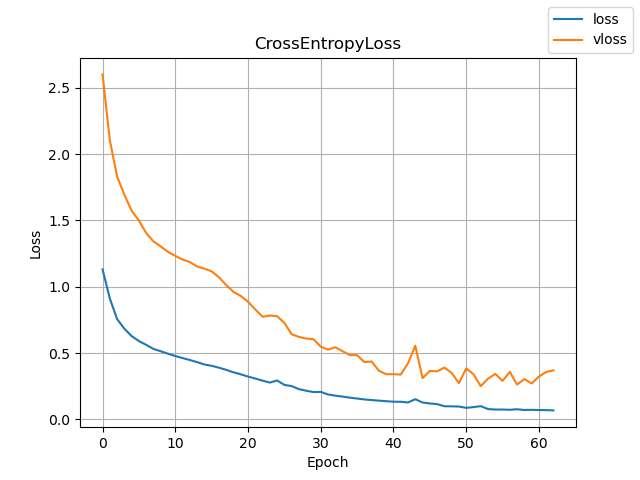

In [127]:
fig, ax = plt.subplots()

ax.plot(trainer.model_results["epoch"],
       trainer.model_results["loss"], label="loss")
ax.plot(trainer.model_results["epoch"],
       trainer.model_results["vloss"], label="vloss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
fig.legend()
ax.grid()
ax.set_title("CrossEntropyLoss")
plt.show()

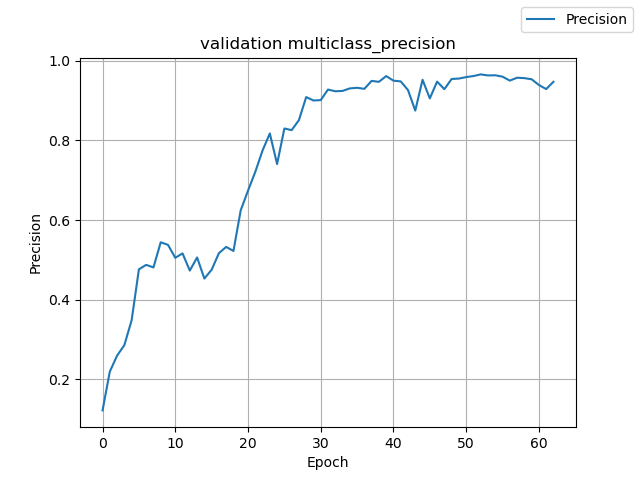

In [128]:
fig, ax = plt.subplots()
values = [a for a in trainer.model_results["vmulticlass_precision"]]
ax.plot(trainer.model_results["epoch"],
       values, label="Precision")


ax.set_xlabel("Epoch")
ax.set_ylabel("Precision")
fig.legend()
ax.grid()
ax.set_title("validation multiclass_precision")
plt.show()